<a href="https://colab.research.google.com/github/mamidinithyasree62-hash/Movie_Reccomendation_System/blob/main/movie_ratings_dashboard_Nithyasree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Create Synthetic Movie Dataset

First, I will do a synthetic dataset with 400 movie records, including `Movie_ID`, `Title`, `Genre`, `Release_Year`, `IMDb_Rating`, `Number_of_Votes`, `Language`, and `Duration_Minutes`. Genres will be varied, `Release_Year` will range from 2000-2024, and `IMDb_Rating` will be between 5.0-9.5. Some movies will have multiple genres separated by a pipe character.

In [ ]:
import pandas as pd
import numpy as np
import random

# Set a seed for reproducibility
np.random.seed(42)
random.seed(42)

num_movies = 400

# Define possible genres and languages
genres = ['Action', 'Comedy', 'Drama', 'Thriller', 'Romance', 'Horror', 'Sci-Fi', 'Animation', 'Mystery', 'Family']
languages = ['English', 'Spanish', 'French', 'German', 'Japanese', 'Korean']

movies = []
for i in range(num_movies):
    movie_id = i + 1
    title = f'Movie Title {movie_id}'

    # Generate 1 or 2 genres, separated by a pipe
    num_genres = random.randint(1, 2)
    selected_genres = random.sample(genres, num_genres)
    genre = '|'.join(selected_genres)

    release_year = random.randint(2000, 2024)
    imdb_rating = round(random.uniform(5.0, 9.5), 1)
    number_of_votes = random.randint(1000, 500000)
    language = random.choice(languages)
    duration_minutes = random.randint(80, 180)

    movies.append({
        'Movie_ID': movie_id,
        'Title': title,
        'Genre': genre,
        'Release_Year': release_year,
        'IMDb_Rating': imdb_rating,
        'Number_of_Votes': number_of_votes,
        'Language': language,
        'Duration_Minutes': duration_minutes
    })

df = pd.DataFrame(movies)

# Save to a CSV file
csv_file_path = 'movies_dataset.csv'
df.to_csv(csv_file_path, index=False)

print(f"Synthetic dataset created and saved to {csv_file_path}")
display(df.head())

Synthetic dataset created and saved to movies_dataset.csv


,Movie_ID,Title,Genre,Release_Year,IMDb_Rating,Number_of_Votes,Language,Duration_Minutes
0,1,Movie Title 1,Action,2023,6.2,118026,Spanish,174
1,2,Movie Title 2,Mystery,2002,7.7,17663,English,91
2,3,Movie Title 3,Thriller,2016,7.7,295254,Spanish,171
3,4,Movie Title 4,Thriller|Animation,2018,6.3,456763,English,177
4,5,Movie Title 5,Sci-Fi,2010,6.3,113886,French,93


### Top 10 Highest-Rated Movies Overall

Next, I will identify and display the top 10 movies based on their `IMDb_Rating`.

In [ ]:
# Sort the DataFrame by 'IMDb_Rating' in descending order and select the top 10
top_10_movies = df.sort_values(by='IMDb_Rating', ascending=False).head(10)

print("Top 10 Highest-Rated Movies Overall:")
display(top_10_movies[['Title', 'Genre', 'IMDb_Rating', 'Release_Year']])

Top 10 Highest-Rated Movies Overall:


,Title,Genre,IMDb_Rating,Release_Year
26,Movie Title 27,Romance,9.5,2012
157,Movie Title 158,Animation|Romance,9.5,2006
185,Movie Title 186,Animation|Action,9.5,2001
289,Movie Title 290,Thriller|Drama,9.5,2015
307,Movie Title 308,Mystery,9.5,2010
343,Movie Title 344,Mystery|Drama,9.4,2023
57,Movie Title 58,Thriller,9.4,2005
36,Movie Title 37,Mystery,9.4,2000
256,Movie Title 257,Animation|Sci-Fi,9.4,2010
88,Movie Title 89,Drama|Animation,9.4,2004


### Calculate Average Rating Per Genre

To understand genre popularity, I will now calculate the average `IMDb_Rating` for each genre. Since movies can have multiple genres, I'll first split the 'Genre' column and then expand the DataFrame before grouping.

In [ ]:
# Split the 'Genre' column where there are multiple genres separated by '|'
genres_split = df['Genre'].str.split('|', expand=True)

# Stack the genres to create a long format DataFrame (one row per genre per movie)
genres_stacked = genres_split.stack()

# Assign a name to the stacked series for easier merging
genres_stacked.name = 'Single_Genre'

# Create a DataFrame with original movie data and the single genres
df_genres_expanded = df.drop('Genre', axis=1).join(genres_stacked.reset_index(level=1, drop=True))

# Calculate the average rating per genre
average_rating_per_genre = df_genres_expanded.groupby('Single_Genre')['IMDb_Rating'].mean().sort_values(ascending=False)

print("Average Rating per Genre:")
display(average_rating_per_genre)

Average Rating per Genre:


,IMDb_Rating
Single_Genre,
Animation,7.586111
Mystery,7.532692
Drama,7.373437
Romance,7.285915
Action,7.272414
Sci-Fi,7.198333
Thriller,7.192157
Comedy,7.180303
Horror,7.083333


### Identify Most Reviewed (Most Popular) Genres

Now, I will determine the most popular genres by counting the occurrences of each `Single_Genre` in the expanded DataFrame. This will show which genres are most frequently assigned to movies in our dataset.

In [ ]:
# Count the occurrences of each single genre to find the most popular ones
most_popular_genres = df_genres_expanded['Single_Genre'].value_counts()

print("Most Popular Genres (by number of movies):")
display(most_popular_genres)

Most Popular Genres (by number of movies):


,count
Single_Genre,
Animation,72
Romance,71
Comedy,66
Drama,64
Sci-Fi,60
Family,59
Action,58
Mystery,52
Thriller,51


### Show How Average Ratings Have Changed Over the Years Using a Line Chart

I will now analyze the trend of `IMDb_Rating` over `Release_Year`. I'll group the data by year and calculate the average rating, then visualize this trend using a line chart to observe any changes over time.

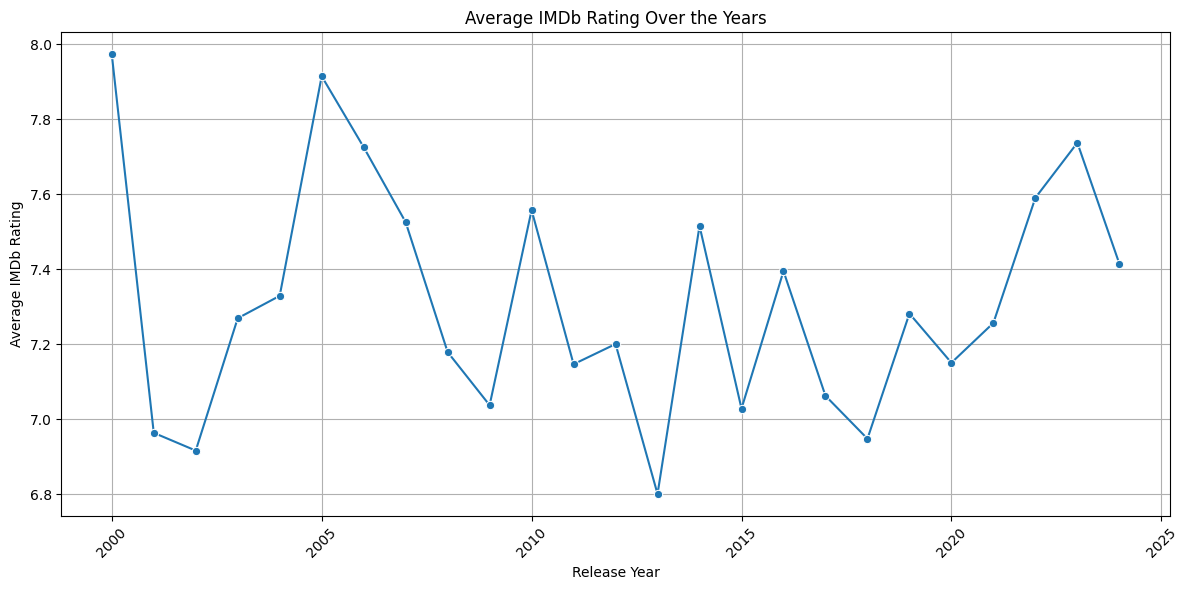

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average rating per release year
average_rating_per_year = df.groupby('Release_Year')['IMDb_Rating'].mean().reset_index()

# Plot the trend of average ratings over the years
plt.figure(figsize=(12, 6))
sns.lineplot(data=average_rating_per_year, x='Release_Year', y='IMDb_Rating', marker='o')
plt.title('Average IMDb Rating Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Average IMDb Rating')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Filter Movies by Genre and Rating Threshold

I will now implement a feature to filter movies based on a user-specified genre and a minimum IMDb rating. This will allow you to find movies that meet specific criteria.

In [ ]:
# Get user input for genre and minimum rating
selected_genre = input("Enter a genre to filter by (e.g., Action, Drama, Sci-Fi): ")
min_rating_str = input("Enter a minimum IMDb rating (e.g., 7.5): ")

try:
    min_rating = float(min_rating_str)
except ValueError:
    print("Invalid rating. Please enter a number.")
    min_rating = 0.0


filtered_movies = df_genres_expanded[
    (df_genres_expanded['Single_Genre'].str.contains(selected_genre, case=False, na=False)) &
    (df_genres_expanded['IMDb_Rating'] >= min_rating)
]

print(f"\nMovies in '{selected_genre}' with IMDb Rating >= {min_rating}:")
display(filtered_movies[['Title', 'Single_Genre', 'IMDb_Rating', 'Release_Year']])

Enter a genre to filter by (e.g., Action, Drama, Sci-Fi): Action
Enter a minimum IMDb rating (e.g., 7.5): 8.5

Movies in 'Action' with IMDb Rating >= 8.5:


,Title,Single_Genre,IMDb_Rating,Release_Year
22,Movie Title 23,Action,9.2,2003
38,Movie Title 39,Action,9.2,2008
77,Movie Title 78,Action,9.1,2007
119,Movie Title 120,Action,9.3,2019
125,Movie Title 126,Action,8.6,2005
128,Movie Title 129,Action,9.3,2007
155,Movie Title 156,Action,9.1,2014
185,Movie Title 186,Action,9.5,2001
241,Movie Title 242,Action,9.2,2010
260,Movie Title 261,Action,8.9,2023


### Find Genres with Consistently High Ratings

To identify genres with consistently high ratings, I'll consider genres that not only have a high average rating but also have a significant number of movies, ensuring the average is not skewed by just a few high-rated films. I'll combine the average rating per genre with the count of movies per genre.

In [ ]:
# Combine average rating and movie count per genre
genre_stats = pd.DataFrame({
    'Average_Rating': average_rating_per_genre,
    'Movie_Count': most_popular_genres
})

# Sort by average rating and then by movie count (as a secondary sort)
genres_consistently_high_ratings = genre_stats.sort_values(by=['Average_Rating', 'Movie_Count'], ascending=[False, False])

print("Genres with Consistently High Ratings (Sorted by Average Rating, then Movie Count):")
display(genres_consistently_high_ratings)

Genres with Consistently High Ratings (Sorted by Average Rating, then Movie Count):


,Average_Rating,Movie_Count
Single_Genre,,
Animation,7.586111,72
Mystery,7.532692,52
Drama,7.373437,64
Romance,7.285915,71
Action,7.272414,58
Sci-Fi,7.198333,60
Thriller,7.192157,51
Comedy,7.180303,66
Horror,7.083333,48


### Visualize Genre Popularity Using a Bar Chart

I will now create a bar chart to visualize the popularity of each genre, using the `most_popular_genres` data calculated earlier. This will provide a clear visual representation of which genres have the highest number of movies.

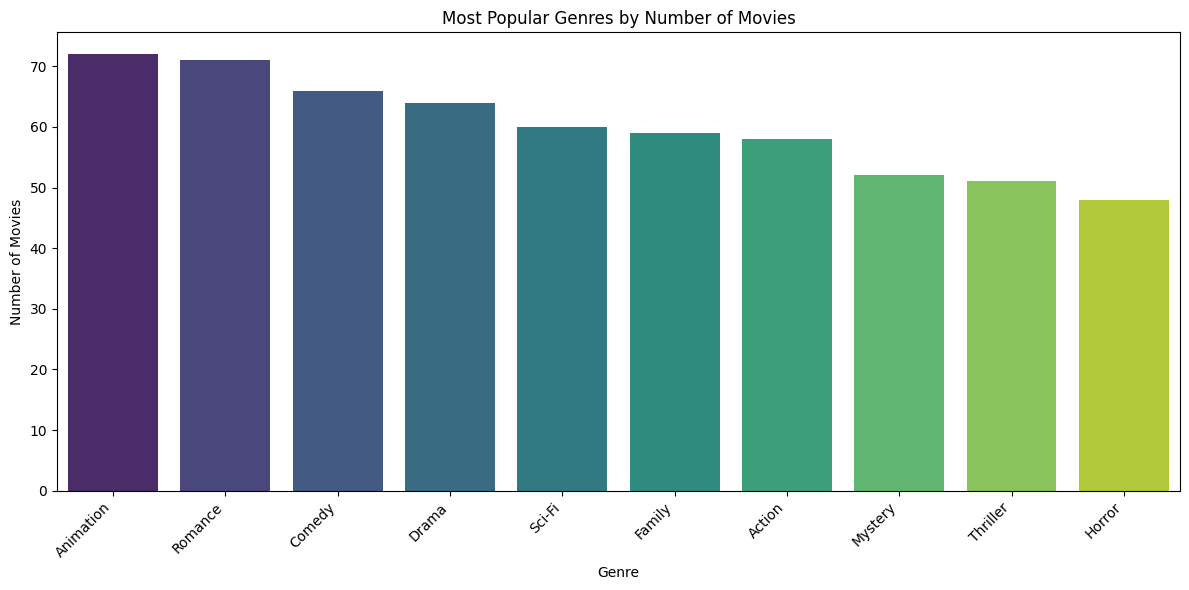

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=most_popular_genres.index, y=most_popular_genres.values, palette='viridis', hue=most_popular_genres.index, legend=False)
plt.title('Most Popular Genres by Number of Movies')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Display Rating Distribution Using a Histogram

To understand the overall distribution of movie ratings, I will create a histogram of the `IMDb_Rating` column. This will show the frequency of movies at different rating levels.

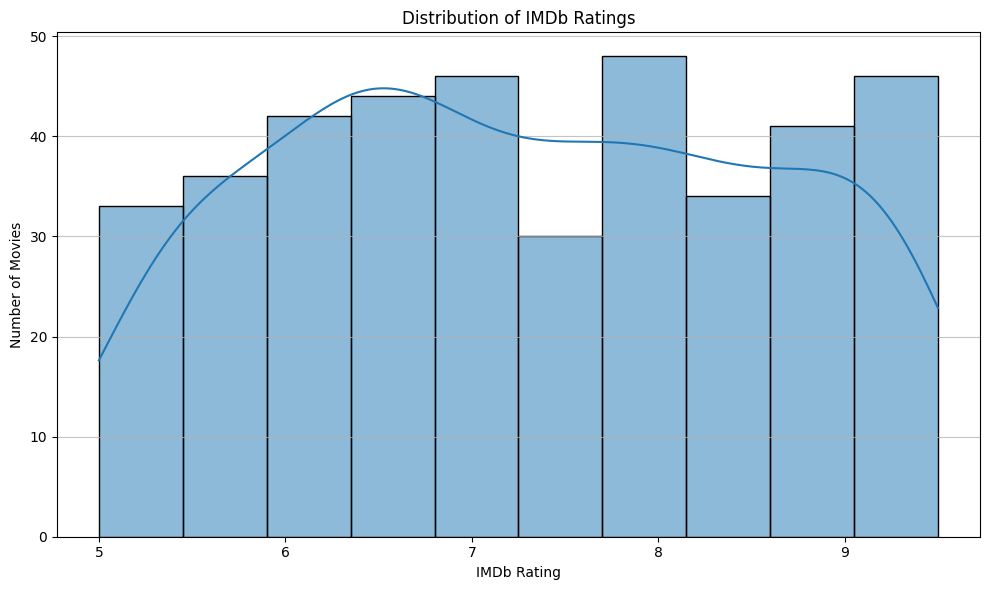

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['IMDb_Rating'], bins=10, kde=True)
plt.title('Distribution of IMDb Ratings')
plt.xlabel('IMDb Rating')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Clean Data: Handle Missing Values and Verify Data Types

I will now check for any missing values, specifically in the `IMDb_Rating` column, and drop any rows that contain them. Additionally, I will verify the data types of key columns to ensure they are suitable for further analysis.

In [ ]:
import pandas as pd

# 1. Drop rows with missing ratings
initial_count = len(df)
df.dropna(subset=['IMDb_Rating'], inplace=True)
print(f"Dropped {initial_count - len(df)} rows with missing ratings.")

# 2. Fix and verify data types
df['Release_Year'] = df['Release_Year'].astype(int)
df['IMDb_Rating'] = df['IMDb_Rating'].astype(float)
df['Number_of_Votes'] = df['Number_of_Votes'].astype(int)
df['Duration_Minutes'] = df['Duration_Minutes'].astype(int)

# 3. Handle multi-genre entries: create a long-form dataframe
# This splits 'Action|Drama' into two rows while keeping other columns linked
df_genres_expanded = df.assign(Genre=df['Genre'].str.split('|')).explode('Genre')
df_genres_expanded.rename(columns={'Genre': 'Single_Genre'}, inplace=True)

print("\nData Cleaning Summary:")
print(f"- Final row count (original): {len(df)}")
print(f"- Final row count (genre-expanded): {len(df_genres_expanded)}")
print("\nColumn Data Types:")
print(df.dtypes)

display(df_genres_expanded.head())


Dropped 0 rows with missing ratings.

Data Cleaning Summary:
- Final row count (original): 400
- Final row count (genre-expanded): 601

Column Data Types:
Movie_ID              int64
Title                object
Genre                object
Release_Year          int64
IMDb_Rating         float64
Number_of_Votes       int64
Language             object
Duration_Minutes      int64
dtype: object


,Movie_ID,Title,Single_Genre,Release_Year,IMDb_Rating,Number_of_Votes,Language,Duration_Minutes
0,1,Movie Title 1,Action,2023,6.2,118026,Spanish,174
1,2,Movie Title 2,Mystery,2002,7.7,17663,English,91
2,3,Movie Title 3,Thriller,2016,7.7,295254,Spanish,171
3,4,Movie Title 4,Thriller,2018,6.3,456763,English,177
3,4,Movie Title 4,Animation,2018,6.3,456763,English,177


### Genre Analysis: Average Rating and Movie Count

As previously executed, the average rating and movie count for each genre have been calculated and are available in the `genre_stats` DataFrame. This table provides a comprehensive overview of each genre's performance in terms of rating and popularity.

In [ ]:
display(genre_stats)

,Average_Rating,Movie_Count
Single_Genre,,
Action,7.272414,58
Animation,7.586111,72
Comedy,7.180303,66
Drama,7.373437,64
Family,7.057627,59
Horror,7.083333,48
Mystery,7.532692,52
Romance,7.285915,71
Sci-Fi,7.198333,60


### Top Movies: Sorted by IMDb_Rating Descending

As previously executed, the top 10 movies based on their `IMDb_Rating` have already been identified. This table shows the highest-rated movies in the dataset.

In [ ]:
# Sort the original DataFrame by rating to get the absolute top movies
top_movies_sorted = df.sort_values(by='IMDb_Rating', ascending=False).head(10)

print("Top 10 Movies by IMDb Rating:")
display(top_movies_sorted[['Title', 'Genre', 'IMDb_Rating', 'Release_Year']])

Top 10 Movies by IMDb Rating:


,Title,Genre,IMDb_Rating,Release_Year
26,Movie Title 27,Romance,9.5,2012
157,Movie Title 158,Animation|Romance,9.5,2006
185,Movie Title 186,Animation|Action,9.5,2001
289,Movie Title 290,Thriller|Drama,9.5,2015
307,Movie Title 308,Mystery,9.5,2010
343,Movie Title 344,Mystery|Drama,9.4,2023
57,Movie Title 58,Thriller,9.4,2005
36,Movie Title 37,Mystery,9.4,2000
256,Movie Title 257,Animation|Sci-Fi,9.4,2010
88,Movie Title 89,Drama|Animation,9.4,2004


### Average IMDb Rating Over the Years

As previously calculated, here is the trend of average IMDb ratings over the years.

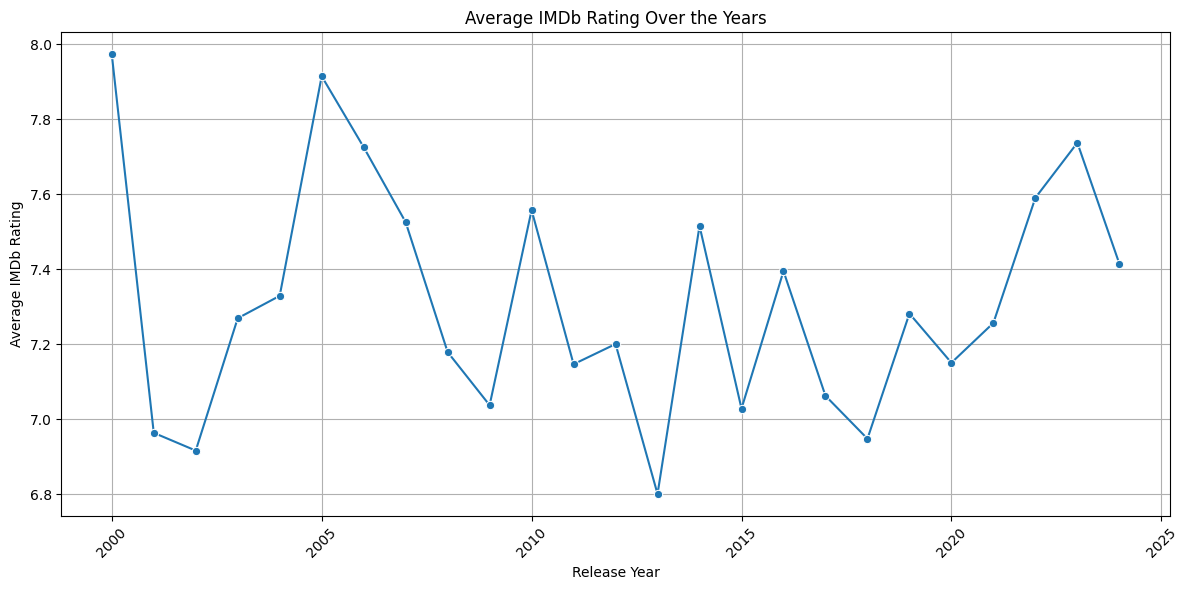

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average rating per release year (already done, just for context)
# average_rating_per_year = df.groupby('Release_Year')['IMDb_Rating'].mean().reset_index()

# Plot the trend of average ratings over the years
plt.figure(figsize=(12, 6))
sns.lineplot(data=average_rating_per_year, x='Release_Year', y='IMDb_Rating', marker='o')
plt.title('Average IMDb Rating Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Average IMDb Rating')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

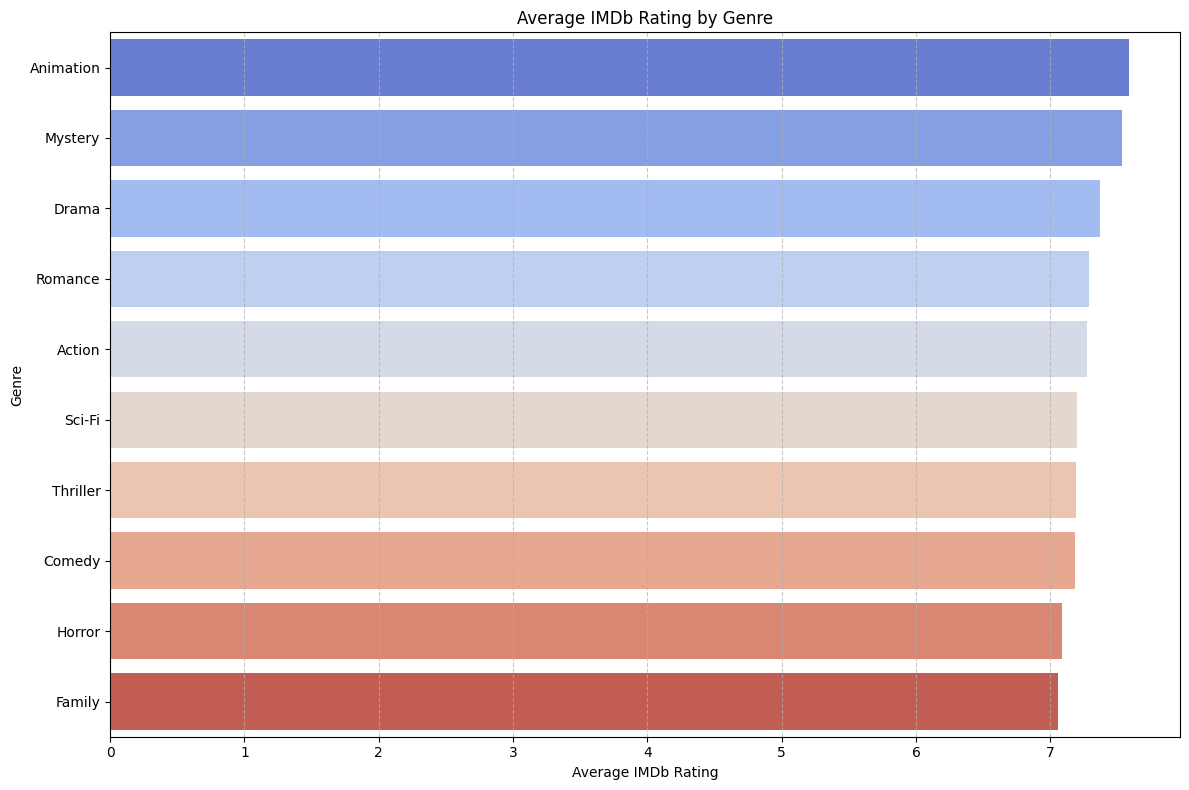

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a horizontal bar chart of average rating per genre
plt.figure(figsize=(12, 8))
sns.barplot(x=average_rating_per_genre.values, y=average_rating_per_genre.index, palette='coolwarm', hue=average_rating_per_genre.index, legend=False)
plt.title('Average IMDb Rating by Genre')
plt.xlabel('Average IMDb Rating')
plt.ylabel('Genre')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Recommend Movies by Genre and Minimum Rating

This section allows you to get movie recommendations by selecting a genre. It will display movies from the chosen genre that have an IMDb rating of 8.0 or higher.

In [ ]:
# Get user input for genre
recommended_genre_input = input("Enter genre(s) for recommendations (e.g., Action, Drama, Sci-Fi, or multiple separated by commas): ")

# Set the minimum rating for recommendations
min_recommendation_rating = 8.0

# Process multiple genres if provided
recommended_genres_list = [g.strip() for g in recommended_genre_input.split(',') if g.strip()]

# Filter movies based on the selected genre(s) and minimum rating
if recommended_genres_list:
    recommended_movies = df_genres_expanded[
        (df_genres_expanded['Single_Genre'].isin(recommended_genres_list)) &
        (df_genres_expanded['IMDb_Rating'] >= min_recommendation_rating)
    ].sort_values(by='IMDb_Rating', ascending=False)
else:
    recommended_movies = pd.DataFrame() # Empty DataFrame if no valid genres were entered

print(f"\nRecommended Movies in {recommended_genres_list} with IMDb Rating >= {min_recommendation_rating}:")
display(recommended_movies[['Title', 'Single_Genre', 'IMDb_Rating', 'Release_Year']])

Enter genre(s) for recommendations (e.g., Action, Drama, Sci-Fi, or multiple separated by commas): Action, Drama, Scifi

Recommended Movies in ['Action', 'Drama', 'Scifi'] with IMDb Rating >= 8.0:


,Title,Single_Genre,IMDb_Rating,Release_Year
289,Movie Title 290,Drama,9.5,2015
185,Movie Title 186,Action,9.5,2001
88,Movie Title 89,Drama,9.4,2004
343,Movie Title 344,Drama,9.4,2023
248,Movie Title 249,Drama,9.4,2016
117,Movie Title 118,Drama,9.3,2018
128,Movie Title 129,Action,9.3,2007
166,Movie Title 167,Drama,9.3,2024
317,Movie Title 318,Drama,9.3,2000
368,Movie Title 369,Drama,9.3,2020


In [ ]:
# Get user input for genre
recommended_genre = input("Enter a genre for recommendations (e.g., Action, Drama, Sci-Fi): ")

# Set the minimum rating for recommendations
min_recommendation_rating = 8.0

# Filter movies based on the selected genre and minimum rating
recommended_movies = df_genres_expanded[
    (df_genres_expanded['Single_Genre'].str.contains(recommended_genre, case=False, na=False)) &
    (df_genres_expanded['IMDb_Rating'] >= min_recommendation_rating)
].sort_values(by='IMDb_Rating', ascending=False)

print(f"\nRecommended Movies in '{recommended_genre}' with IMDb Rating >= {min_recommendation_rating}:")
display(recommended_movies[['Title', 'Single_Genre', 'IMDb_Rating', 'Release_Year']])

Enter a genre for recommendations (e.g., Action, Drama, Sci-Fi): sci-fi

Recommended Movies in 'sci-fi' with IMDb Rating >= 8.0:


,Title,Single_Genre,IMDb_Rating,Release_Year
274,Movie Title 275,Sci-Fi,9.4,2004
256,Movie Title 257,Sci-Fi,9.4,2010
210,Movie Title 211,Sci-Fi,9.3,2000
288,Movie Title 289,Sci-Fi,9.3,2007
38,Movie Title 39,Sci-Fi,9.2,2008
341,Movie Title 342,Sci-Fi,8.9,2014
32,Movie Title 33,Sci-Fi,8.9,2014
364,Movie Title 365,Sci-Fi,8.9,2018
91,Movie Title 92,Sci-Fi,8.8,2008
338,Movie Title 339,Sci-Fi,8.7,2008


In [ ]:
display(top_10_movies[['Title', 'Genre', 'IMDb_Rating', 'Release_Year']])

,Title,Genre,IMDb_Rating,Release_Year
26,Movie Title 27,Romance,9.5,2012
157,Movie Title 158,Animation|Romance,9.5,2006
185,Movie Title 186,Animation|Action,9.5,2001
289,Movie Title 290,Thriller|Drama,9.5,2015
307,Movie Title 308,Mystery,9.5,2010
343,Movie Title 344,Mystery|Drama,9.4,2023
57,Movie Title 58,Thriller,9.4,2005
36,Movie Title 37,Mystery,9.4,2000
256,Movie Title 257,Animation|Sci-Fi,9.4,2010
88,Movie Title 89,Drama|Animation,9.4,2004


In [ ]:
# Display current data types
print("\nCurrent DataFrame Info:")
df.info()

# Verify and convert data types if necessary (though synthetic data should largely be correct)
# Ensure 'Release_Year' is int, 'IMDb_Rating' is float, 'Number_of_Votes' is int, 'Duration_Minutes' is int
df['Release_Year'] = df['Release_Year'].astype(int)
df['IMDb_Rating'] = df['IMDb_Rating'].astype(float)
df['Number_of_Votes'] = df['Number_of_Votes'].astype(int)
df['Duration_Minutes'] = df['Duration_Minutes'].astype(int)

print("\nData types after verification/conversion:")
df.info()


Current DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Movie_ID          400 non-null    int64  
 1   Title             400 non-null    object 
 2   Genre             400 non-null    object 
 3   Release_Year      400 non-null    int64  
 4   IMDb_Rating       400 non-null    float64
 5   Number_of_Votes   400 non-null    int64  
 6   Language          400 non-null    object 
 7   Duration_Minutes  400 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 25.1+ KB

Data types after verification/conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Movie_ID          400 non-null    int64  
 1   Title             400 non-null    object 
 2 